# Intermediate Model Analysis
**BRIM Systems** | Prepared by: Brian Davis

---

## Purpose

Exploratory analysis against dbt intermediate model output. Reads from the enriched
fact tables produced by the intermediate layer — where all five source systems are
joined for the first time — to surface cross-system patterns, validate analytical
assumptions, and inform mart model and dashboard design.

**Section flow:**
1. Configuration & Data Loading
2. Intermediate Table Summary (preview, schema/nulls, grain verification)
3. Cross-System Correlation Matrix
4. Additional Analyses (Defect Rate Analysis, Scrap Cost Attribution, Operator & Certification Analysis)

## 0. Environment Setup

In [1]:
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import linregress, ttest_ind

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.4f}".format)

BRAND_BLUE   = "#3D5166"
BRAND_ACCENT = "#6B8FA8"
WARN_AMBER   = "#D4881E"
FAIL_RED     = "#B94040"
PASS_GREEN   = "#4A7C59"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#CCCCCC", "axes.grid": True,
    "grid.color": "#EEEEEE", "grid.linestyle": "-",
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
    "figure.dpi": 120,
})

print("Environment ready.")

Environment ready.


## 1. Configuration & Data Loading

In [2]:
# ── Database connection ────────────────────────────────────────────────────
DB_PATH = Path("../data_source/defects_scrap.duckdb").resolve()

# ── Intermediate table name constants ─────────────────────────────────────
TBL_INT_ORDERS  = "int_quality__orders_enriched"
TBL_INT_SCRAP     = "int_quality__scrap_costs"

# ── Primary keys ───────────────────────────────────────────────────────────
PK_MAP = {
    TBL_INT_ORDERS: "work_order_id",
    TBL_INT_SCRAP:    "scrap_id",
}

In [3]:
# ── Load tables ───────────────────────────────────────────────────────────
con = duckdb.connect(str(DB_PATH))
dfs = {}

print(f"{'Table':<45} {'Rows':>8}  {'Cols':>5}")
print("-" * 65)

for tbl in [TBL_INT_ORDERS, TBL_INT_SCRAP]:
    df = con.execute(f"SELECT * FROM {tbl}").df()
    dfs[tbl] = df
    print(f"  ✓  {tbl:<42} {len(df):>8,}  {len(df.columns):>5}")

orders = dfs[TBL_INT_ORDERS]
scrap    = dfs[TBL_INT_SCRAP]

print("\nTables loaded successfully.")

Table                                             Rows   Cols
-----------------------------------------------------------------


  ✓  int_quality__orders_enriched                  8,573     40


  ✓  int_quality__scrap_costs                      4,420     32

Tables loaded successfully.


## 2. Intermediate Table Summary

### 2.1 Preview

In [4]:
for tbl, df in dfs.items():
    print(f"\n{'='*70}")
    print(f"  {tbl.upper()}  ({len(df):,} rows  x  {len(df.columns)} columns)")
    print(f"{'='*70}")
    display(df.head())


  INT_QUALITY__ORDERS_ENRICHED  (8,573 rows  x  40 columns)


,work_order_id,inspection_id,part_number,customer,shift_code,complexity,material_type,requires_welding,lot_id,order_date,actual_start,inspection_date,quantity_ordered,quantity_inspected,quantity_passed,quantity_failed,defect_rate,defect_code,disposition,is_anomalous_timestamp,schedule_variance_hrs,std_labor_hrs,inspector_id,machine_id,machine_name,machine_type,machine_age_years,machine_location,operator_id,operator_name,operator_home_shift,cert_level,specialization,welding_cert_current,hire_date,welding_cert_mismatch,supplier,lot_cert_status,lot_receipt_date,unit_cost_per_lb
0,WO-10003,INSP-4,P-1016,Customer G,Shift A,Low,14ga Steel,False,LOT-1003,2023-01-02,2023-01-02 07:05:00,2023-01-02 08:48:06.480925,25,25,24,1,0.0400,Dimensional,Scrap,False,1,4.1300,OP009,M05,Welding Station 1,Welding,6,Bay C,OP018,Derek Zuniga,Shift A,Level 2,Bending,True,2019-11-20,False,Supplier A,Certified,2023-01-02,1.4950
1,WO-10006,INSP-7,P-1029,Customer B,Shift B,Low,"1/4"" Plate",True,LOT-1002,2023-01-02,2023-01-02 15:53:00,2023-01-02 19:40:00.019988,6,6,6,0,0.0000,None,Pass,False,0,3.6400,OP019,M04,Press Brake 2,Bending,2,Bay B,OP008,Gina Moore,Shift B,Level 3,General,True,2014-10-07,False,Supplier C,Certified,2023-01-02,2.3700
2,WO-10008,INSP-10,P-1029,Customer B,Shift A,Low,"1/4"" Plate",True,LOT-1002,2023-01-03,2023-01-03 07:23:00,2023-01-03 09:58:55.385343,9,9,9,0,0.0000,None,Pass,False,0,3.6400,OP003,M06,Welding Station 2,Welding,4,Bay C,OP013,Lisa Hensley,Shift A,Level 3,General,True,2024-11-23,False,Supplier C,Certified,2023-01-02,2.3700
3,WO-10009,INSP-11,P-1003,Customer D,Shift A,Medium,"1/4"" Plate",False,LOT-1002,2023-01-03,2023-01-03 07:38:00,2023-01-03 09:50:53.154793,17,17,16,1,0.0588,Dimensional,Rework,False,1,4.6300,OP018,M04,Press Brake 2,Bending,2,Bay B,OP005,Cristian Santos,Shift A,Level 1,Bending,True,2024-06-29,False,Supplier C,Certified,2023-01-02,2.3700
4,WO-10019,INSP-22,P-1006,Customer B,Shift A,Medium,"1/4"" Plate",False,LOT-1002,2023-01-04,2023-01-04 06:15:00,2023-01-04 08:53:00.288428,22,22,22,0,0.0000,None,Pass,False,1,2.5700,OP010,M02,Laser Cutter 2,Laser Cutting,8,Bay A,OP017,Holly Wood,Shift A,Level 1,Bending,True,2025-05-09,False,Supplier C,Certified,2023-01-02,2.3700



  INT_QUALITY__SCRAP_COSTS  (4,420 rows  x  32 columns)


,scrap_id,work_order_id,inspection_id,scrap_date,scrap_reason,defect_code,quantity_scrapped,quantity_reworked,material_cost_per_unit,labor_cost_per_unit,total_scrap_cost,part_number,customer,machine_id,machine_name,machine_type,machine_age_years,operator_id,operator_name,shift_code,complexity,material_type,supplier,lot_id,lot_cert_status,welding_cert_current,welding_cert_mismatch,order_defect_rate,order_date,actual_start,scrap_date_1,scrap_month
0,SCRAP-1,WO-10001,INSP-2,2023-01-02 10:41:14.937846,SETUP_ERROR,Dimensional,0,2,0.6900,20.1300,0.0000,P-1032,Customer F,M06,Welding Station 2,Welding,4,OP019,Lisa Jackson,Shift A,Medium,Aluminum 5052,None,None,None,True,False,0.1538,2023-01-02,2023-01-02 07:14:00,2023-01-02 10:41:14.937846,2023-01-01
1,SCRAP-2,WO-10002,INSP-3,2023-01-02 19:19:19.517729,OPERATOR_ERROR,Dimensional,1,1,6.0600,35.0000,41.0600,P-1010,Customer A,M03,Press Brake 1,Bending,12,OP010,Ryan Munoz,Shift B,Low,Stainless 304,None,None,None,True,False,0.2500,2023-01-02,2023-01-02 15:06:00,2023-01-02 19:19:19.517729,2023-01-01
2,SCRAP-3,WO-10003,INSP-4,2023-01-02 08:48:06.480925,OPERATOR_ERROR,Dimensional,0,1,3.2000,32.7900,0.0000,P-1016,Customer G,M05,Welding Station 1,Welding,6,OP018,Derek Zuniga,Shift A,Low,14ga Steel,Supplier A,LOT-1003,Certified,True,False,0.0400,2023-01-02,2023-01-02 07:05:00,2023-01-02 08:48:06.480925,2023-01-01
3,SCRAP-4,WO-10007,INSP-9,2023-01-03 20:03:56.147080,MACHINE_ISSUE,Surface Scratch,1,1,5.7600,28.0700,33.8300,P-1025,Customer C,M06,Welding Station 2,Welding,4,OP003,Angie Henderson,Shift B,Medium,Stainless 304,None,None,None,True,False,0.1176,2023-01-03,2023-01-03 15:13:00,2023-01-03 20:03:56.147080,2023-01-01
4,SCRAP-5,WO-10009,INSP-11,2023-01-03 09:50:53.154793,SETUP_ERROR,Dimensional,0,1,1.3000,49.3200,0.0000,P-1003,Customer D,M04,Press Brake 2,Bending,2,OP005,Cristian Santos,Shift A,Medium,"1/4"" Plate",Supplier C,LOT-1002,Certified,True,False,0.0588,2023-01-03,2023-01-03 07:38:00,2023-01-03 09:50:53.154793,2023-01-01


### 2.2 Schema & Null Flags

In [5]:
# ── Null thresholds ────────────────────────────────────────────────────────
NULL_WARN_PCT = 0
NULL_FAIL_PCT = 10.0

In [6]:
def schema_summary(df):
    rows = []
    for col in df.columns:
        s        = df[col]
        null_ct  = s.isna().sum()
        null_pct = null_ct / len(df) * 100
        rows.append({
            "column":     col,
            "dtype":      str(s.dtype),
            "null_count": null_ct,
            "null_pct":   round(null_pct, 1),
            "n_unique":   s.nunique(dropna=True),
            "sample":     str(s.dropna().iloc[0])[:60] if null_ct < len(df) else "(all null)",
        })
    return pd.DataFrame(rows)

for tbl, df in dfs.items():
    print(f"\n{'='*70}\n  {tbl.upper()}  ({len(df):,} rows, {len(df.columns)} columns)\n{'='*70}")
    display(
        schema_summary(df).style
        .format({"null_pct": "{:.1f}%"})
        .applymap(
            lambda v: "background-color: #F8D7DA" if isinstance(v, float) and v > NULL_FAIL_PCT else
                      "background-color: #FFF3CD" if isinstance(v, float) and v > NULL_WARN_PCT else "",
            subset=["null_pct"]
        )
        .set_properties(**{"font-size": "11px"})
    )


  INT_QUALITY__ORDERS_ENRICHED  (8,573 rows, 40 columns)


,column,dtype,null_count,null_pct,n_unique,sample
0,work_order_id,object,0,0.0%,8573,WO-10003
1,inspection_id,object,0,0.0%,8573,INSP-4
2,part_number,object,0,0.0%,35,P-1016
3,customer,object,0,0.0%,8,Customer G
4,shift_code,object,0,0.0%,2,Shift A
5,complexity,object,0,0.0%,3,Low
6,material_type,object,0,0.0%,7,14ga Steel
7,requires_welding,bool,0,0.0%,2,False
8,lot_id,object,55,0.6%,879,LOT-1003
9,order_date,datetime64[us],0,0.0%,812,2023-01-02 00:00:00



  INT_QUALITY__SCRAP_COSTS  (4,420 rows, 32 columns)


,column,dtype,null_count,null_pct,n_unique,sample
0,scrap_id,object,0,0.0%,4420,SCRAP-1
1,work_order_id,object,0,0.0%,4139,WO-10001
2,inspection_id,object,0,0.0%,4420,INSP-2
3,scrap_date,datetime64[us],0,0.0%,4420,2023-01-02 10:41:14.937846
4,scrap_reason,object,0,0.0%,6,SETUP_ERROR
5,defect_code,object,0,0.0%,7,Dimensional
6,quantity_scrapped,int32,0,0.0%,12,0
7,quantity_reworked,int32,0,0.0%,8,2
8,material_cost_per_unit,float64,0,0.0%,1679,0.69
9,labor_cost_per_unit,float64,0,0.0%,3048,20.13


### 2.3 Grain Verification

Confirms the join logic in the intermediate models did not introduce fanout.
Each model should retain exactly one row per its declared grain.

In [7]:
print(f"{'Table':<45} {'PK':<22} {'Total':>8}  {'Unique':>8}  {'Dupes':>8}  Status")
print("-" * 100)

for tbl, pk in PK_MAP.items():
    df      = dfs[tbl]
    total   = len(df)
    unique  = df[pk].nunique()
    dupes   = total - unique
    status  = "✓ PASS" if dupes == 0 else "✗ FAIL — join introduced fanout"
    print(f"  {status[:1]}  {tbl:<42} {pk:<22} {total:>8,}  {unique:>8,}  {dupes:>8,}  {status}")

Table                                         PK                        Total    Unique     Dupes  Status
----------------------------------------------------------------------------------------------------
  ✓  int_quality__orders_enriched               work_order_id             8,573     8,573         0  ✓ PASS
  ✓  int_quality__scrap_costs                   scrap_id                  4,420     4,420         0  ✓ PASS


---
## 3. Cross-System Correlation Matrix

In [8]:
# ── Columns to include in correlation matrix ──────────────────────────────
# Boolean and binary columns are cast to int (0/1) so they appear in the matrix.
# Non-numeric and high-cardinality ID columns are excluded.
CORR_EXCLUDE = [
    "work_order_id", "inspection_id", "part_number", "customer",
    "machine_id", "operator_id", "lot_id", "inspector_id",
    "machine_name", "operator_name", "machine_location",
    "defect_code", "disposition", "material_type",
    "shift_code", "complexity", "supplier", "lot_cert_status",
    "specialization", "cert_level", "operator_home_shift",
]

corr_df = orders.copy()

# Cast boolean columns to int
bool_cols = corr_df.select_dtypes(include="bool").columns.tolist()
for col in bool_cols:
    corr_df[col] = corr_df[col].astype(int)

# Drop excluded and non-numeric columns
corr_df = corr_df.drop(columns=[c for c in CORR_EXCLUDE if c in corr_df.columns], errors="ignore")
corr_df = corr_df.select_dtypes(include="number")

print(f"Columns included in correlation matrix ({len(corr_df.columns)}):")
print(corr_df.columns.tolist())

Columns included in correlation matrix (13):
['requires_welding', 'quantity_ordered', 'quantity_inspected', 'quantity_passed', 'quantity_failed', 'defect_rate', 'is_anomalous_timestamp', 'schedule_variance_hrs', 'std_labor_hrs', 'machine_age_years', 'welding_cert_current', 'welding_cert_mismatch', 'unit_cost_per_lb']


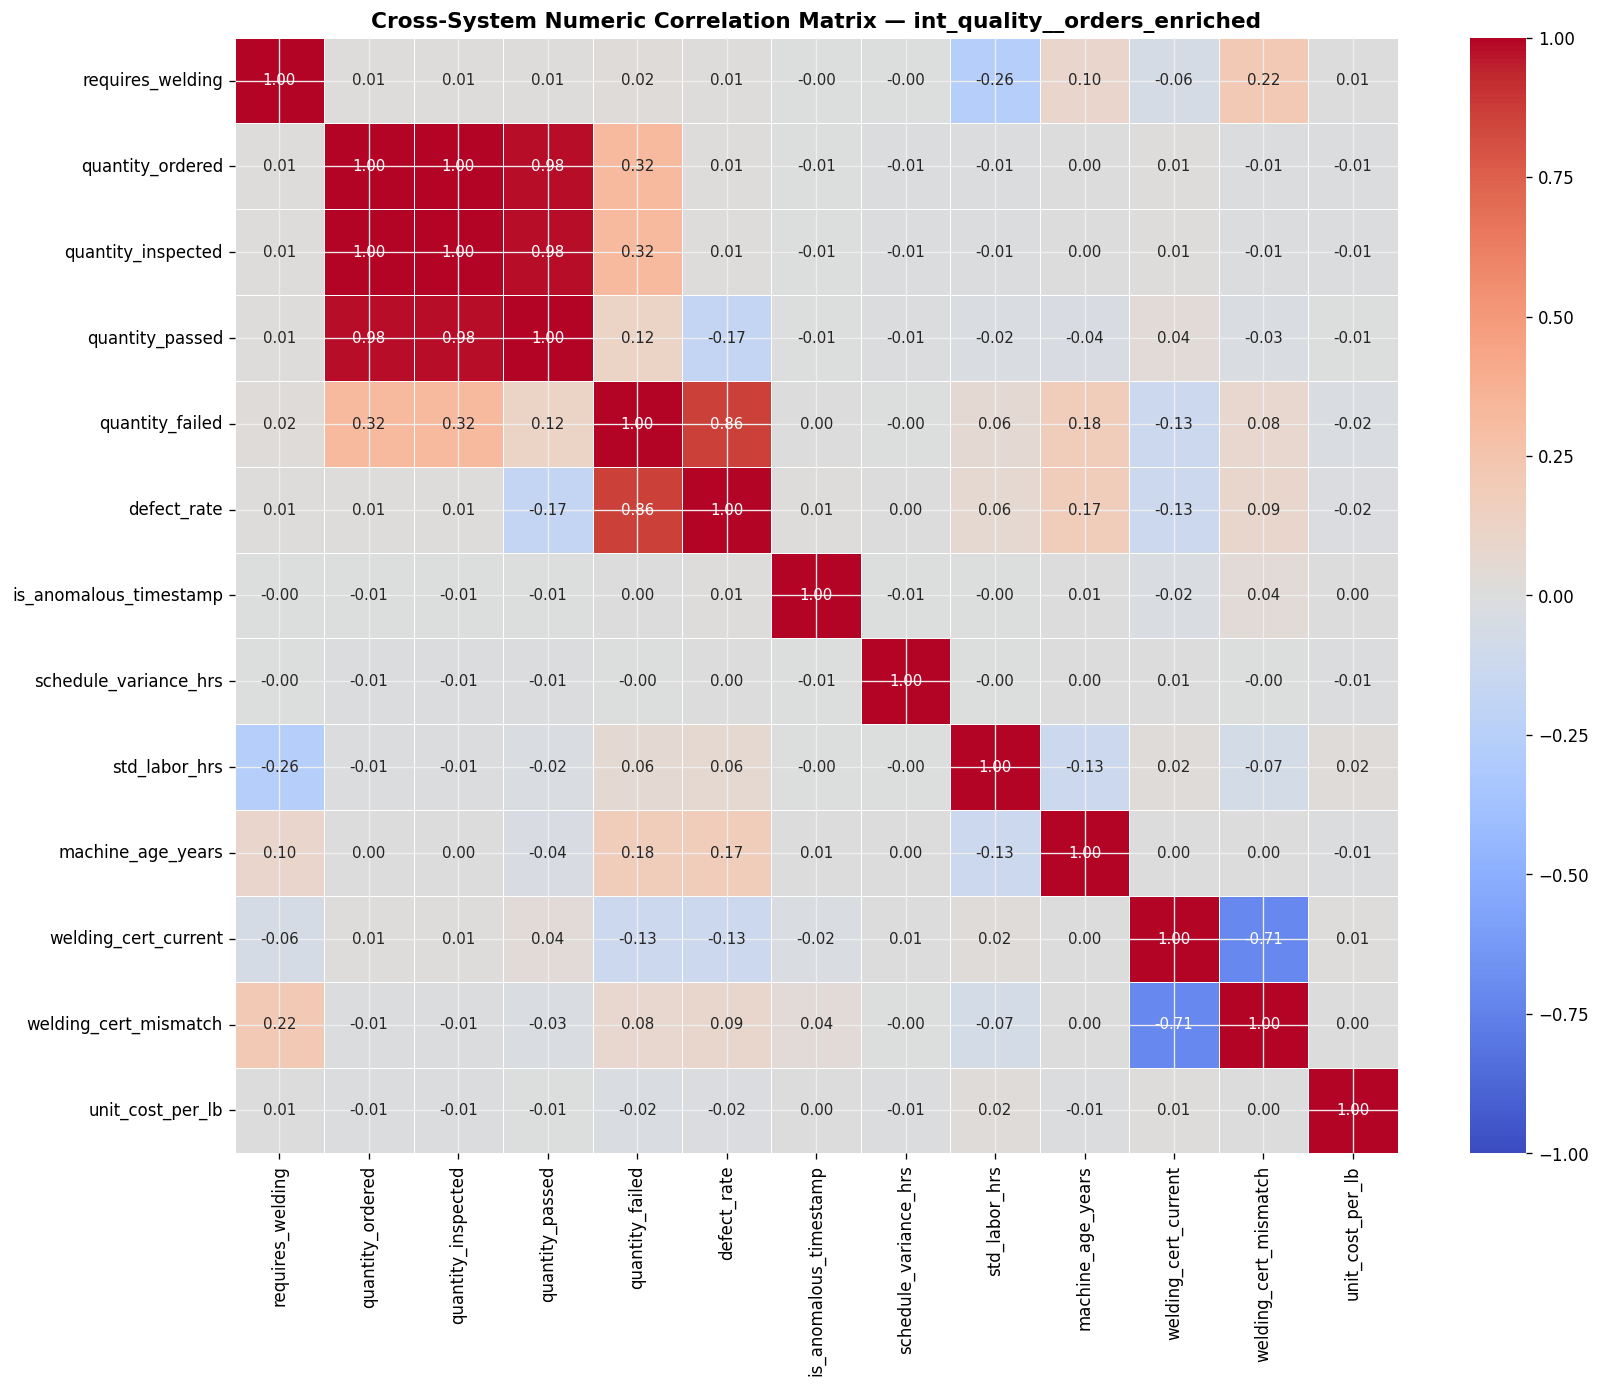


Correlations with defect_rate (absolute value, descending):
quantity_failed          0.8596
machine_age_years        0.1733
quantity_passed          0.1719
welding_cert_current     0.1288
welding_cert_mismatch    0.0932
std_labor_hrs            0.0639
unit_cost_per_lb         0.0169
requires_welding         0.0116
quantity_inspected       0.0096
quantity_ordered         0.0096
is_anomalous_timestamp   0.0086
schedule_variance_hrs    0.0020


In [9]:
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(max(8, len(corr_df.columns) * 1.1),
                                max(6, len(corr_df.columns) * 0.9)))
sns.heatmap(
    corr_matrix, ax=ax,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, linecolor="white",
    vmin=-1, vmax=1,
    annot_kws={"size": 9}
)
ax.set_title("Cross-System Numeric Correlation Matrix — int_quality__orders_enriched")
plt.tight_layout()
plt.show()

# ── Highlight strongest correlations with defect_rate ─────────────────────
if "defect_rate" in corr_matrix.columns:
    dr_corr = (
        corr_matrix["defect_rate"]
        .drop("defect_rate")
        .abs()
        .sort_values(ascending=False)
    )
    print("\nCorrelations with defect_rate (absolute value, descending):")
    print(dr_corr.to_string())

---
## 4. Defect Rate Analysis

In [10]:
# ── Analysis config ───────────────────────────────────────────────────────
# Minimum work orders per group to include in rate analysis.
# Groups below this threshold are shown but flagged as low-n.
MIN_GROUP_SIZE = 10

# Working dataframe — exclude rows with null defect_rate (uninspected)
df_dr = orders.dropna(subset=["defect_rate"]).copy()
print(f"Rows with valid defect_rate: {len(df_dr):,} of {len(orders):,}")

Rows with valid defect_rate: 8,573 of 8,573


### 4.1 Overall Defect Rate Distribution

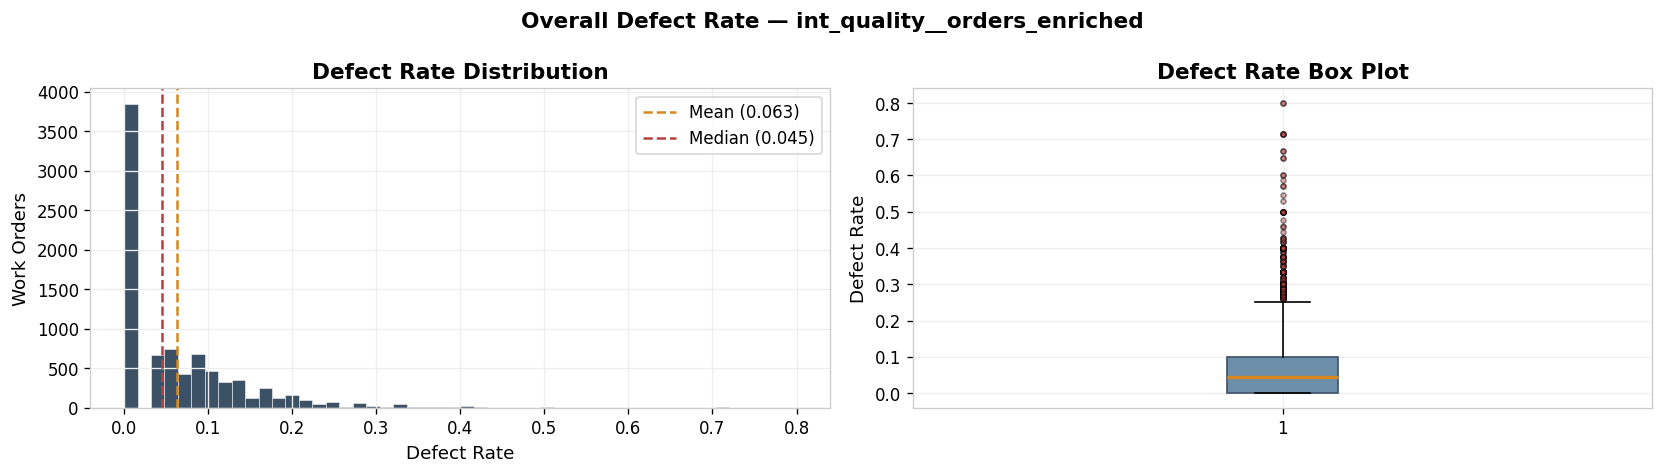


Summary statistics — defect_rate:
count   8,573.0000
mean        0.0626
std         0.0806
min         0.0000
25%         0.0000
50%         0.0455
75%         0.1000
max         0.8000


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df_dr["defect_rate"], bins=50, color=BRAND_BLUE,
             edgecolor="white", linewidth=0.3)
axes[0].axvline(df_dr["defect_rate"].mean(), color=WARN_AMBER,
                linestyle="--", linewidth=1.5,
                label=f"Mean ({df_dr['defect_rate'].mean():.3f})")
axes[0].axvline(df_dr["defect_rate"].median(), color=FAIL_RED,
                linestyle="--", linewidth=1.5,
                label=f"Median ({df_dr['defect_rate'].median():.3f})")
axes[0].set_title("Defect Rate Distribution")
axes[0].set_xlabel("Defect Rate")
axes[0].set_ylabel("Work Orders")
axes[0].legend()

# Box plot
axes[1].boxplot(df_dr["defect_rate"], vert=True, patch_artist=True,
                boxprops=dict(facecolor=BRAND_ACCENT, color=BRAND_BLUE),
                medianprops=dict(color=WARN_AMBER, linewidth=2),
                flierprops=dict(marker="o", markersize=3,
                                markerfacecolor=FAIL_RED, alpha=0.4))
axes[1].set_title("Defect Rate Box Plot")
axes[1].set_ylabel("Defect Rate")

plt.suptitle("Overall Defect Rate — int_quality__orders_enriched",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary stats
print("\nSummary statistics — defect_rate:")
print(df_dr["defect_rate"].describe().to_string())

### 4.2 Defect Rate by Dimension

One chart per pattern dimension. Each chart shows mean defect rate per group
with group size (n) annotated. Groups below `MIN_GROUP_SIZE` are flagged.

In [12]:
def defect_rate_by_dimension(df, dim_col, title, highlight_col=None):
    """
    Bar chart of mean defect rate grouped by dim_col.
    Annotates each bar with group size. Highlights a specific group if provided.
    """
    grouped = (
        df.groupby(dim_col)["defect_rate"]
        .agg(mean_defect_rate="mean", n="count")
        .reset_index()
        .sort_values("mean_defect_rate", ascending=False)
    )
    grouped["low_n"] = grouped["n"] < MIN_GROUP_SIZE

    colors = []
    for _, row in grouped.iterrows():
        if row["low_n"]:
            colors.append(WARN_AMBER)
        elif highlight_col and row[dim_col] == highlight_col:
            colors.append(FAIL_RED)
        else:
            colors.append(BRAND_BLUE)

    fig, ax = plt.subplots(figsize=(max(8, len(grouped) * 1.2), 5))
    bars = ax.bar(range(len(grouped)), grouped["mean_defect_rate"],
                  color=colors, width=0.65)

    # Annotate bars with n
    for i, (_, row) in enumerate(grouped.iterrows()):
        label = f"n={row['n']:,}"
        if row["low_n"]:
            label += " ⚠"
        ax.text(i, row["mean_defect_rate"] + 0.001, label,
                ha="center", va="bottom", fontsize=9)

    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels(grouped[dim_col].astype(str), rotation=30, ha="right")
    ax.set_ylabel("Mean Defect Rate")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.3f}"))

    # Overall mean reference line
    overall_mean = df["defect_rate"].mean()
    ax.axhline(overall_mean, color=WARN_AMBER, linestyle="--", linewidth=1.2,
               label=f"Overall mean ({overall_mean:.3f})")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n{title} — group summary:")
    display(grouped.reset_index(drop=True))

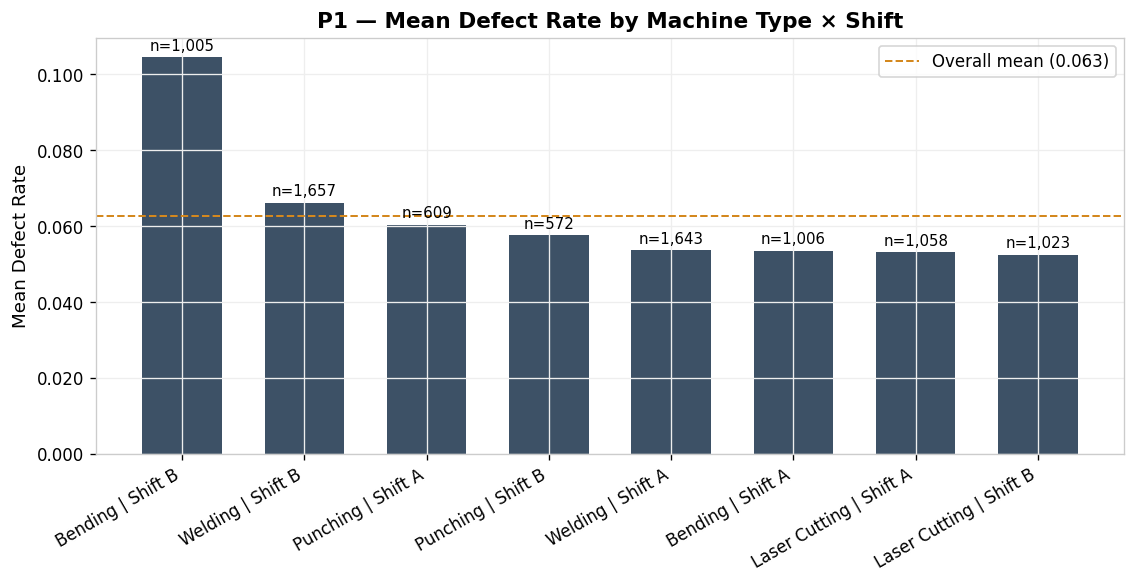


P1 — Mean Defect Rate by Machine Type × Shift — group summary:


,machine_x_shift,mean_defect_rate,n,low_n
0,Bending | Shift B,0.1045,1005,False
1,Welding | Shift B,0.0661,1657,False
2,Punching | Shift A,0.0604,609,False
3,Punching | Shift B,0.0576,572,False
4,Welding | Shift A,0.0537,1643,False
5,Bending | Shift A,0.0535,1006,False
6,Laser Cutting | Shift A,0.0532,1058,False
7,Laser Cutting | Shift B,0.0525,1023,False


In [13]:
# ── P1: Machine Type × Shift Code ─────────────────────────────────────────
df_p1 = df_dr.copy()
df_p1["machine_x_shift"] = df_p1["machine_type"] + " | " + df_p1["shift_code"].fillna("(no shift)")

defect_rate_by_dimension(
    df_p1, "machine_x_shift",
    "P1 — Mean Defect Rate by Machine Type × Shift",
    highlight_col="Press Brake | Shift B"
)

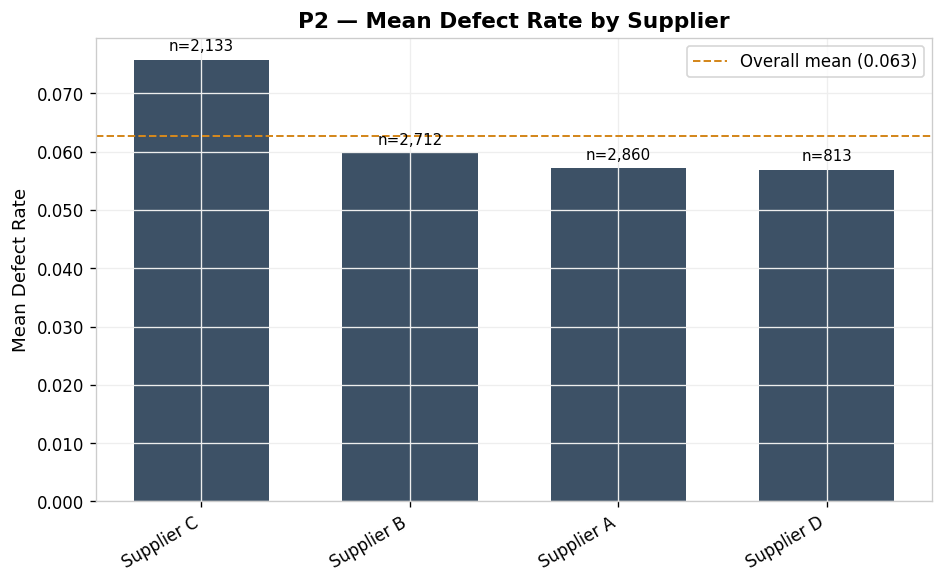


P2 — Mean Defect Rate by Supplier — group summary:


,supplier,mean_defect_rate,n,low_n
0,Supplier C,0.0758,2133,False
1,Supplier B,0.0597,2712,False
2,Supplier A,0.0572,2860,False
3,Supplier D,0.0569,813,False


In [14]:
# ── P2: Supplier ──────────────────────────────────────────────────────────
defect_rate_by_dimension(
    df_dr.dropna(subset=["supplier"]),
    "supplier",
    "P2 — Mean Defect Rate by Supplier",
)

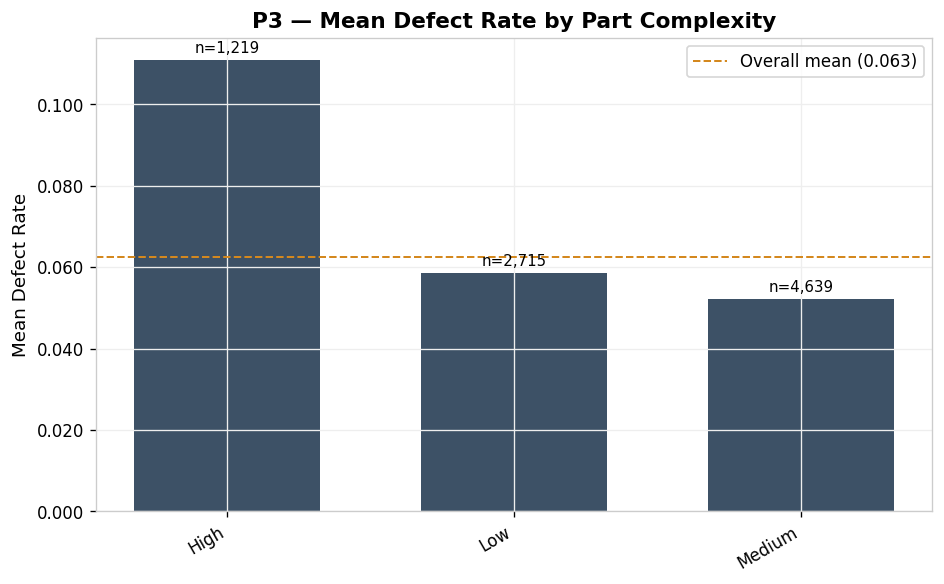


P3 — Mean Defect Rate by Part Complexity — group summary:


,complexity,mean_defect_rate,n,low_n
0,High,0.1108,1219,False
1,Low,0.0585,2715,False
2,Medium,0.0523,4639,False


In [15]:
# ── P3: Complexity ────────────────────────────────────────────────────────
defect_rate_by_dimension(
    df_dr,
    "complexity",
    "P3 — Mean Defect Rate by Part Complexity",
)

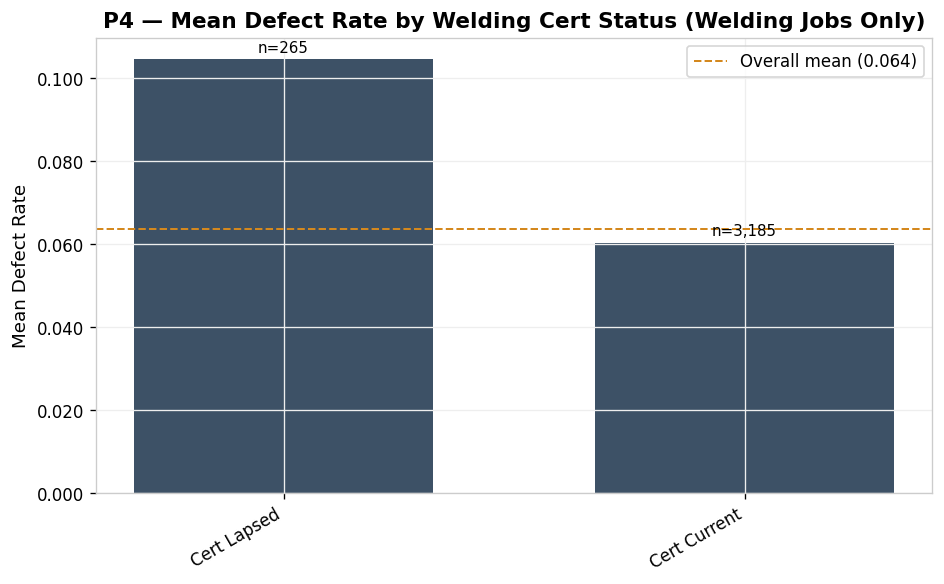


P4 — Mean Defect Rate by Welding Cert Status (Welding Jobs Only) — group summary:


,cert_status,mean_defect_rate,n,low_n
0,Cert Lapsed,0.1046,265,False
1,Cert Current,0.0603,3185,False


In [16]:
# ── P4: Welding Cert Mismatch ─────────────────────────────────────────────
df_p4 = df_dr[df_dr["requires_welding"] == True].copy()
df_p4["cert_status"] = df_p4["welding_cert_mismatch"].map(
    {True: "Cert Lapsed", False: "Cert Current"}
)

defect_rate_by_dimension(
    df_p4,
    "cert_status",
    "P4 — Mean Defect Rate by Welding Cert Status (Welding Jobs Only)",
)

---
## 5. Scrap Cost Attribution

Total and average scrap costs broken down by the key analytical dimensions.
Cross-references defect rate with cost impact — a high defect rate dimension
is not necessarily the highest cost dimension if the affected parts have low
material or labor values.

In [17]:
# ── Time series config ────────────────────────────────────────────────────
# Numeric columns to plot as monthly time series against scrap_month.
SCRAP_TIME_SERIES_METRICS = ["total_scrap_cost", "quantity_scrapped"]

### 5.1 Total Scrap Cost by Dimension

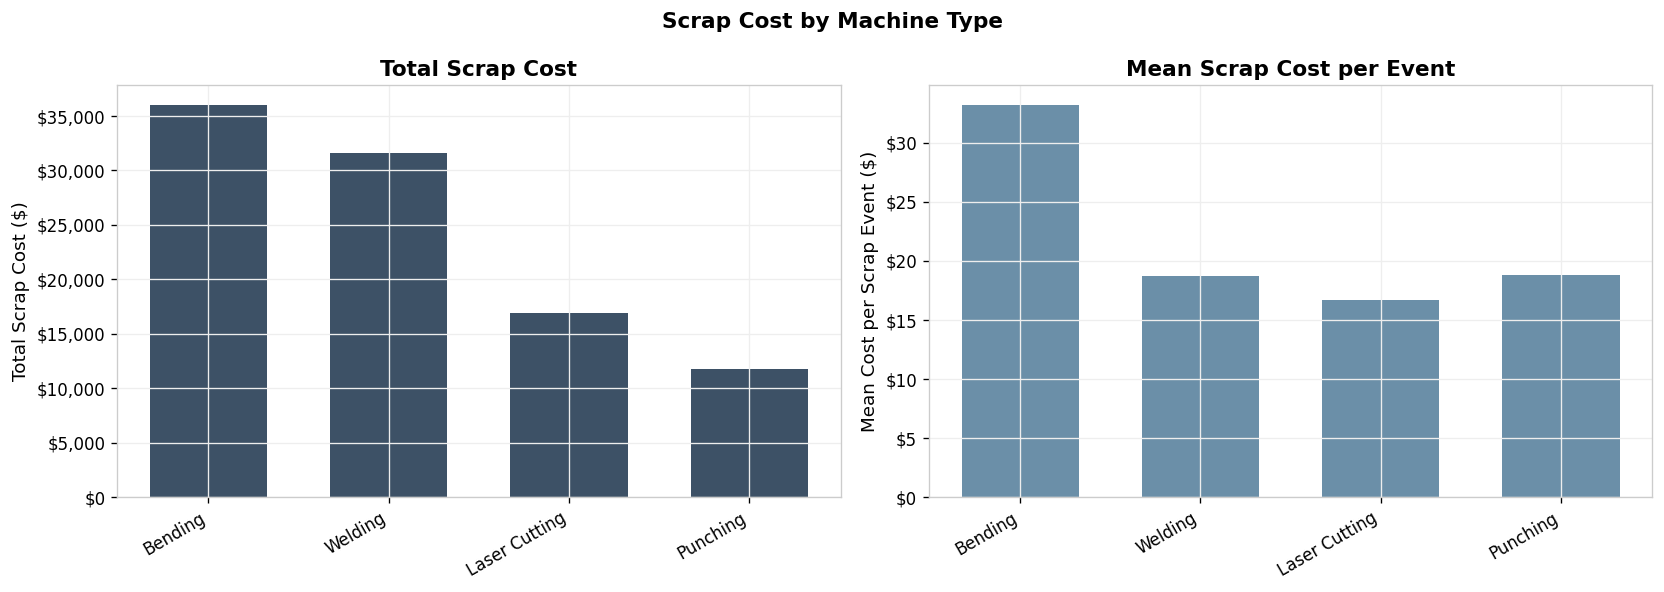


Scrap Cost by Machine Type — group summary:


,machine_type,total_cost,mean_cost,n
0,Bending,"35,991.1200",33.1715,1085
1,Welding,"31,601.8200",18.6662,1693
2,Laser Cutting,"16,926.0600",16.6595,1016
3,Punching,"11,774.1900",18.8086,626


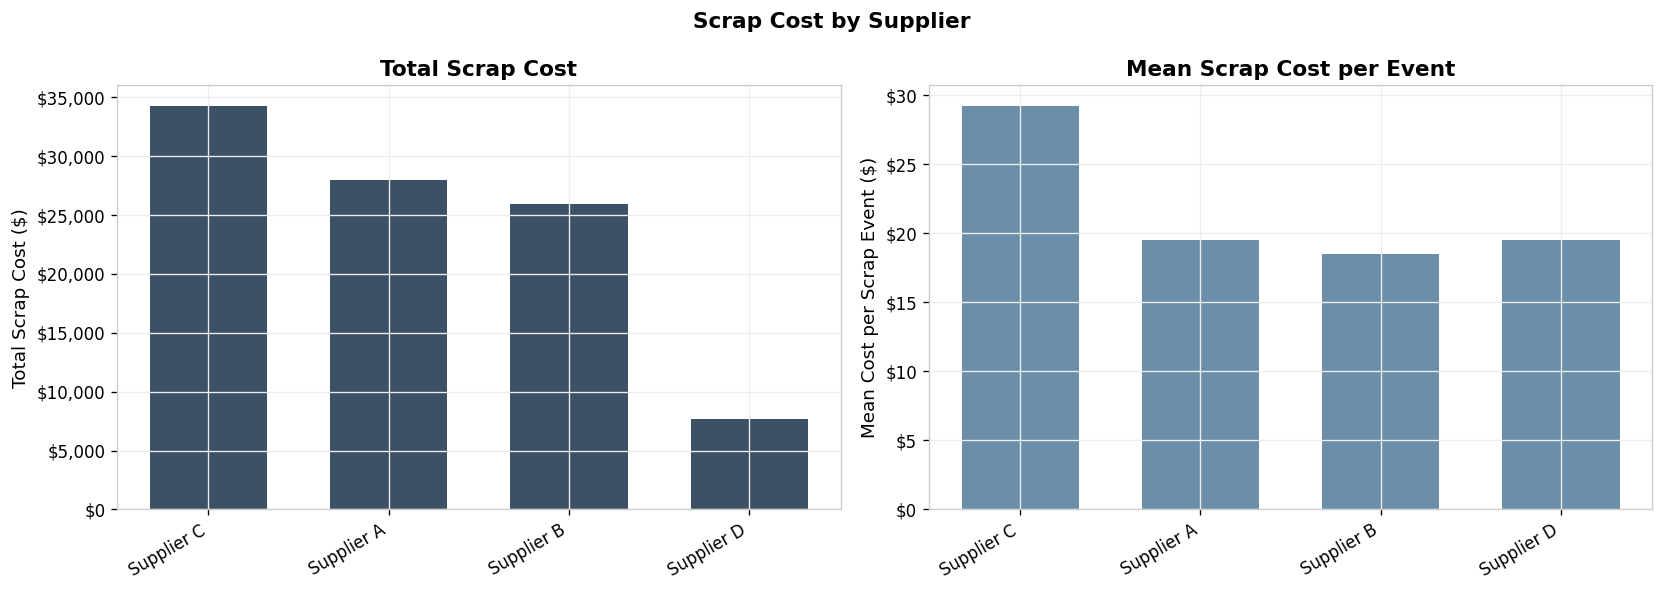


Scrap Cost by Supplier — group summary:


,supplier,total_cost,mean_cost,n
0,Supplier C,"34,270.5000",29.2660,1171
1,Supplier A,"27,965.9900",19.5021,1434
2,Supplier B,"25,948.5400",18.5347,1400
3,Supplier D,"7,650.7800",19.5173,392


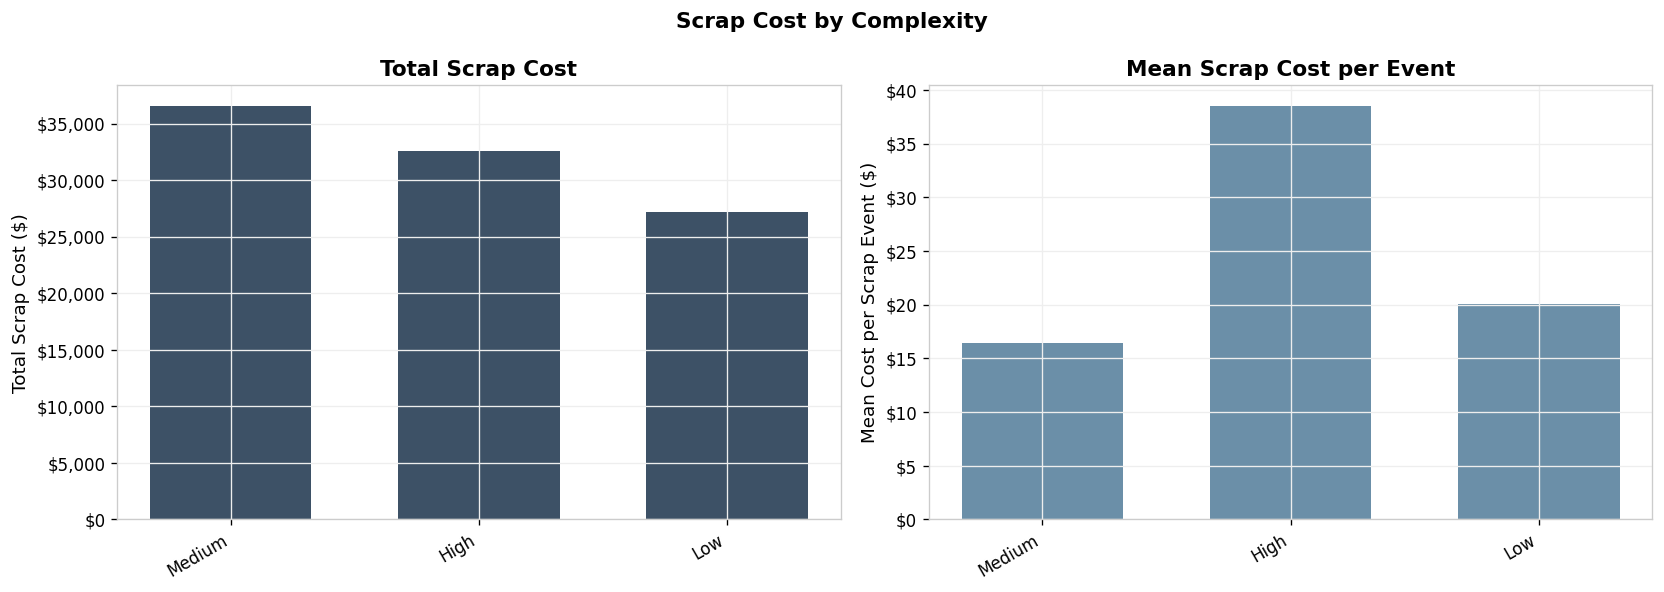


Scrap Cost by Complexity — group summary:


,complexity,total_cost,mean_cost,n
0,Medium,"36,544.7200",16.4839,2217
1,High,"32,535.6700",38.5038,845
2,Low,"27,212.8000",20.0389,1358


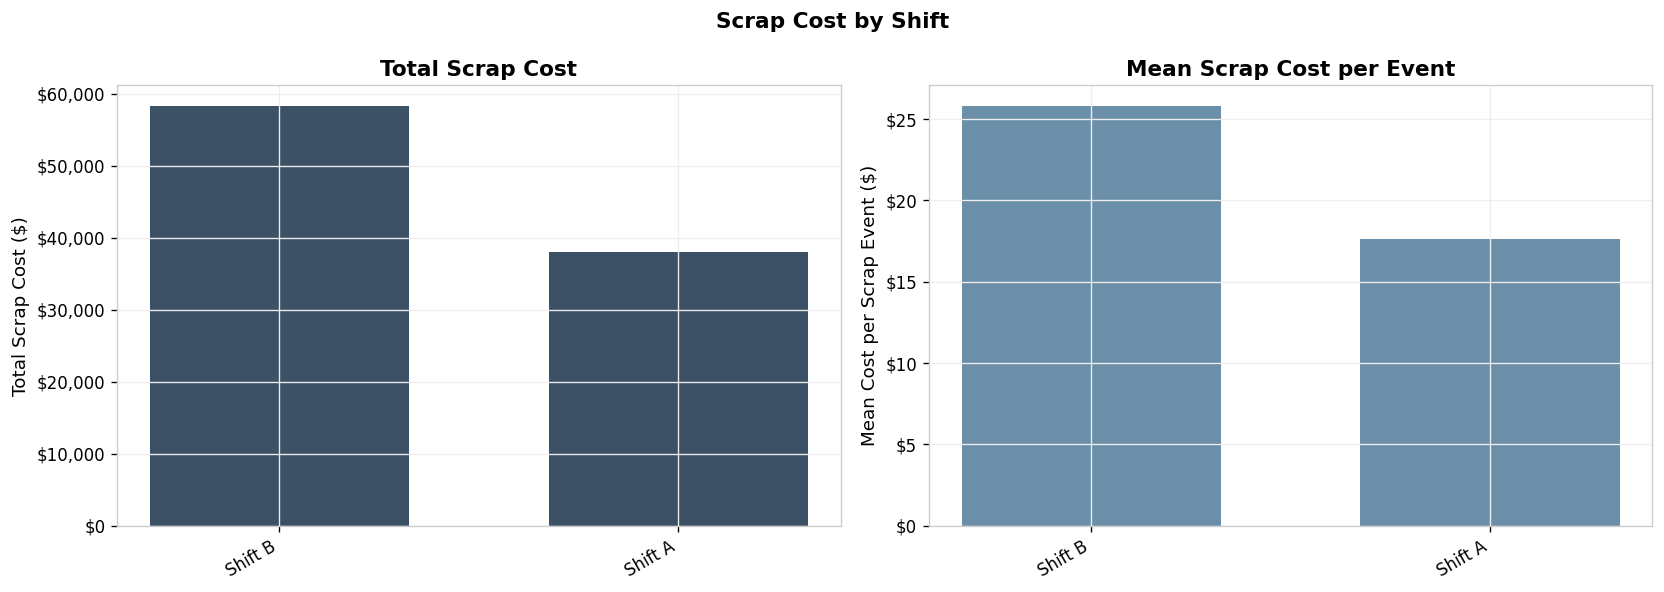


Scrap Cost by Shift — group summary:


,shift_code,total_cost,mean_cost,n
0,Shift B,"58,228.8500",25.7878,2258
1,Shift A,"38,064.3400",17.6061,2162


In [18]:
def scrap_cost_by_dimension(df, dim_col, title):
    """Bar chart of total and mean scrap cost grouped by dim_col."""
    grouped = (
        df.groupby(dim_col)["total_scrap_cost"]
        .agg(total_cost="sum", mean_cost="mean", n="count")
        .reset_index()
        .sort_values("total_cost", ascending=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Total cost
    axes[0].bar(range(len(grouped)), grouped["total_cost"],
                color=BRAND_BLUE, width=0.65)
    axes[0].set_xticks(range(len(grouped)))
    axes[0].set_xticklabels(grouped[dim_col].astype(str), rotation=30, ha="right")
    axes[0].set_ylabel("Total Scrap Cost ($)")
    axes[0].set_title("Total Scrap Cost")
    axes[0].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    )

    # Mean cost per event
    axes[1].bar(range(len(grouped)), grouped["mean_cost"],
                color=BRAND_ACCENT, width=0.65)
    axes[1].set_xticks(range(len(grouped)))
    axes[1].set_xticklabels(grouped[dim_col].astype(str), rotation=30, ha="right")
    axes[1].set_ylabel("Mean Cost per Scrap Event ($)")
    axes[1].set_title("Mean Scrap Cost per Event")
    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    )

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"\n{title} — group summary:")
    display(grouped.reset_index(drop=True))

scrap_cost_by_dimension(scrap, "machine_type",  "Scrap Cost by Machine Type")
scrap_cost_by_dimension(scrap, "supplier",      "Scrap Cost by Supplier")
scrap_cost_by_dimension(scrap, "complexity",    "Scrap Cost by Complexity")
scrap_cost_by_dimension(scrap, "shift_code",    "Scrap Cost by Shift")

### 5.2 Defect Rate vs Scrap Cost Scatter

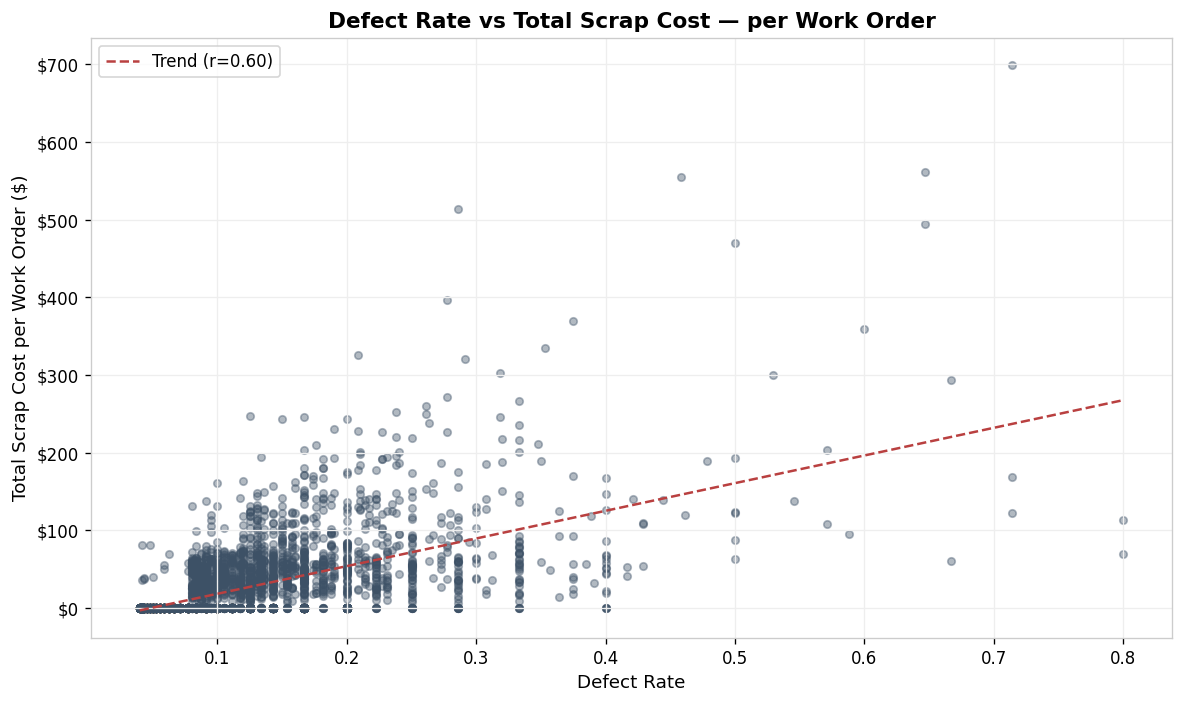

Pearson r (defect_rate vs total_scrap_cost): 0.595


In [19]:
# Join mean defect rate per work order to total scrap cost per work order.
# Each point is one work order.
scatter_df = (
    scrap.groupby("work_order_id")["total_scrap_cost"].sum()
    .reset_index()
    .merge(
        orders[["work_order_id", "defect_rate", "machine_type",
                  "complexity", "supplier"]].dropna(subset=["defect_rate"]),
        on="work_order_id", how="inner"
    )
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(scatter_df["defect_rate"], scatter_df["total_scrap_cost"],
           alpha=0.4, s=20, color=BRAND_BLUE)

# Trend line
x = scatter_df["defect_rate"].values
y = scatter_df["total_scrap_cost"].values
slope, intercept, r, _, _ = linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color=FAIL_RED,
        linewidth=1.5, linestyle="--", label=f"Trend (r={r:.2f})")

ax.set_xlabel("Defect Rate")
ax.set_ylabel("Total Scrap Cost per Work Order ($)")
ax.set_title("Defect Rate vs Total Scrap Cost — per Work Order")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pearson r (defect_rate vs total_scrap_cost): {r:.3f}")

### 5.3 Monthly Scrap Cost Trend

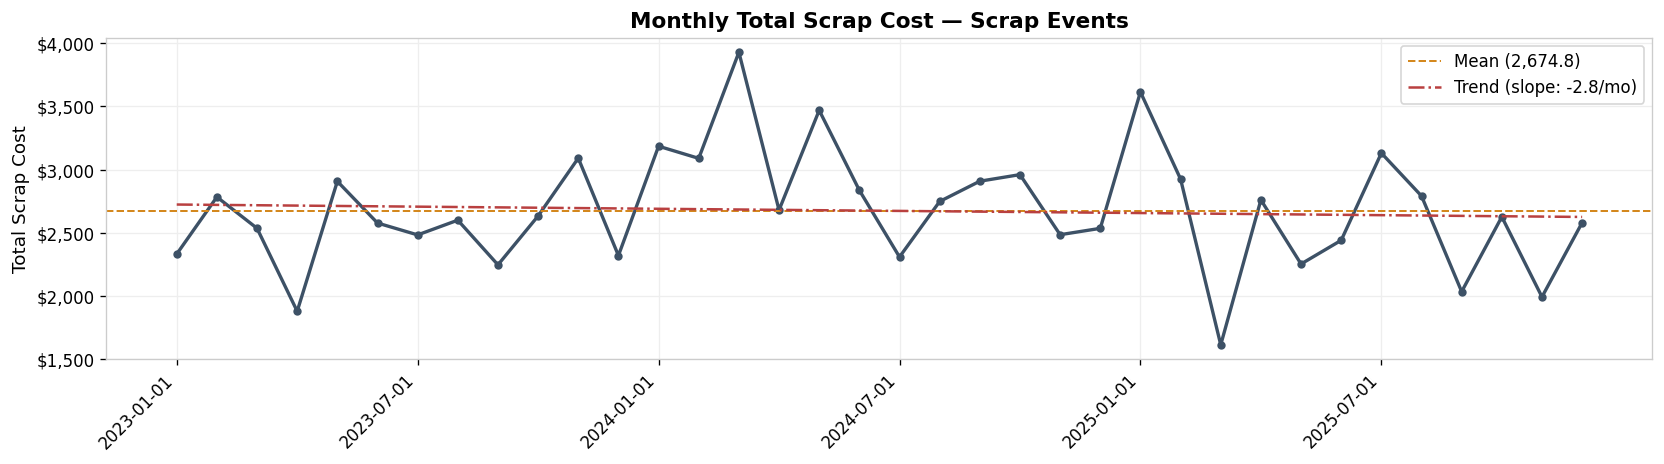


total_scrap_cost — monthly summary:
  Mean:   2,674.8
  Std:    471.2
  Min:    1,614.6  (2025-03-01 00:00:00)
  Max:    3,928.1  (2024-03-01 00:00:00)
  Trend:  -2.80 per month


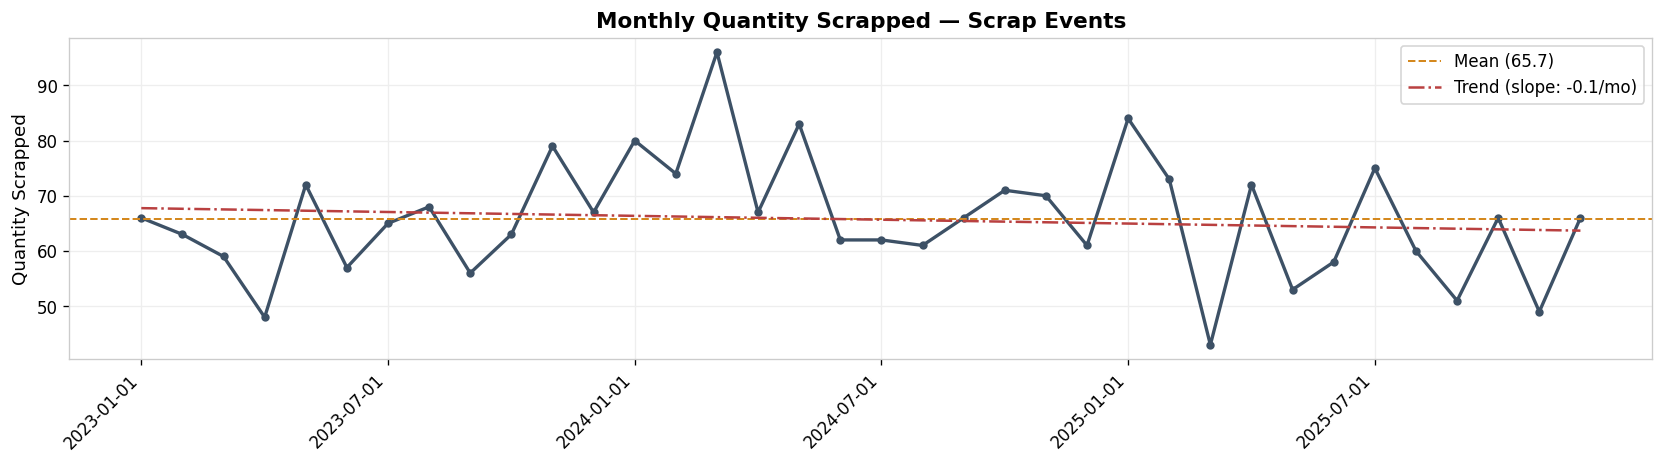


quantity_scrapped — monthly summary:
  Mean:   65.7
  Std:    10.9
  Min:    43.0  (2025-03-01 00:00:00)
  Max:    96.0  (2024-03-01 00:00:00)
  Trend:  -0.12 per month


In [20]:
for metric in SCRAP_TIME_SERIES_METRICS:
    if metric not in scrap.columns:
        print(f"Column {metric} not found — skipping.")
        continue

    monthly = (
        scrap.groupby("scrap_month")[metric]
        .sum()
        .reset_index()
        .sort_values("scrap_month")
    )
    s   = monthly[metric]
    x_n = np.arange(len(s))
    slope, intercept, _, _, _ = linregress(x_n, s)
    trend = slope * x_n + intercept

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(monthly["scrap_month"].astype(str), s,
            color=BRAND_BLUE, linewidth=2, marker="o", markersize=4)
    ax.axhline(s.mean(), color=WARN_AMBER, linestyle="--", linewidth=1.2,
               label=f"Mean ({s.mean():,.1f})")
    ax.plot(monthly["scrap_month"].astype(str), trend,
            color=FAIL_RED, linewidth=1.5, linestyle="-.",
            label=f"Trend (slope: {slope:+.1f}/mo)")
    ax.set_title(f"Monthly {metric.replace('_', ' ').title()} — Scrap Events")
    ax.set_ylabel(metric.replace("_", " ").title())

    fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}") if "cost" in metric           else mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    ax.yaxis.set_major_formatter(fmt)

    xticks = monthly["scrap_month"].astype(str)[::6]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, rotation=45, ha="right")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n{metric} — monthly summary:")
    print(f"  Mean:   {s.mean():,.1f}")
    print(f"  Std:    {s.std():,.1f}")
    print(f"  Min:    {s.min():,.1f}  ({monthly.loc[s.idxmin(), 'scrap_month']})")
    print(f"  Max:    {s.max():,.1f}  ({monthly.loc[s.idxmax(), 'scrap_month']})")
    print(f"  Trend:  {slope:+.2f} per month")

### 5.4 Top Work Orders by Scrap Cost

In [21]:
# ── Config ────────────────────────────────────────────────────────────────
TOP_N_ORDERS = 20

top_orders = (
    scrap.groupby("work_order_id")["total_scrap_cost"].sum()
    .reset_index()
    .sort_values("total_scrap_cost", ascending=False)
    .head(TOP_N_ORDERS)
    .merge(
        orders[["work_order_id", "part_number", "machine_type",
                  "shift_code", "operator_id", "supplier",
                  "complexity", "defect_rate", "welding_cert_mismatch"]],
        on="work_order_id", how="left"
    )
)

print(f"Top {TOP_N_ORDERS} work orders by total scrap cost:")
display(top_orders.reset_index(drop=True))

Top 20 work orders by total scrap cost:


,work_order_id,total_scrap_cost,part_number,machine_type,shift_code,operator_id,supplier,complexity,defect_rate,welding_cert_mismatch
0,WO-10499,699.4900,P-1021,Bending,Shift B,OP014,Supplier C,High,0.7143,False
1,WO-17612,562.0500,P-1021,Bending,Shift B,OP012,Supplier C,High,0.6471,False
2,WO-14263,555.0000,P-1021,Bending,Shift B,OP001,Supplier C,High,0.4583,False
3,WO-13352,514.1800,P-1022,Bending,Shift B,OP010,Supplier D,Medium,0.2857,False
4,WO-13838,495.1000,P-1021,Bending,Shift B,OP007,Supplier C,High,0.6471,False
5,WO-17051,470.1000,P-1021,Bending,Shift B,OP001,Supplier C,High,0.5000,False
6,WO-13242,397.1500,P-1021,Bending,Shift B,OP012,Supplier A,High,0.2778,False
7,WO-16895,369.1800,P-1021,Bending,Shift B,OP012,Supplier A,High,0.3750,False
8,WO-10489,359.3600,P-1021,Bending,Shift B,OP014,Supplier C,High,0.6000,False
9,WO-11464,334.9300,P-1005,Punching,Shift A,OP020,Supplier C,Low,0.3529,False


---
## 6. Operator & Certification Analysis

### 6.1 Defect Rate by Operator

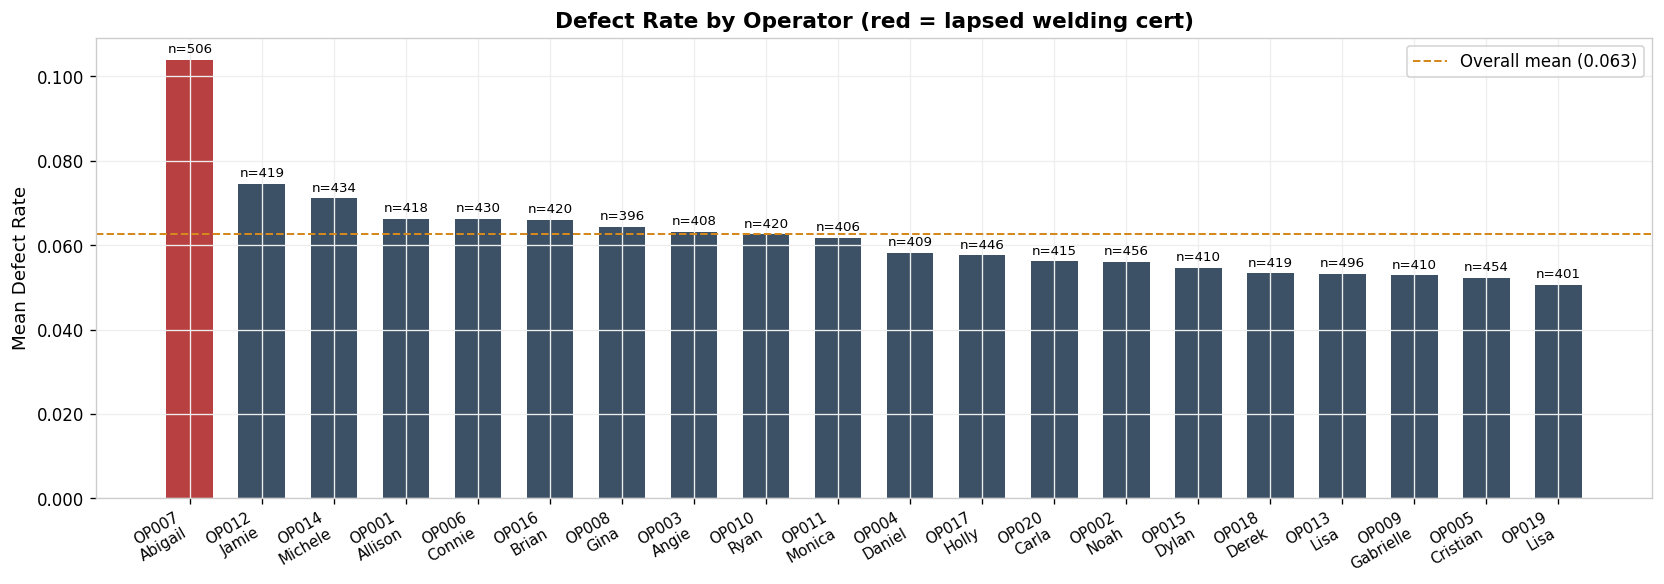


Operator summary (all operators with sufficient job volume):


,operator_id,operator_name,welding_cert_current,cert_level,specialization,mean_defect_rate,n_jobs
0,OP007,Abigail Shaffer,False,Level 1,Welding,0.1040,506
1,OP012,Jamie Arnold,True,Level 3,Laser,0.0745,419
2,OP014,Michele Williams,True,Level 1,Laser,0.0711,434
3,OP001,Allison Hill,True,Level 2,Welding,0.0663,418
4,OP006,Connie Lawrence,True,Level 1,Bending,0.0663,430
5,OP016,Brian Ramirez,True,Level 1,Bending,0.0659,420
6,OP008,Gina Moore,True,Level 3,General,0.0644,396
7,OP003,Angie Henderson,True,Level 2,General,0.0632,408
8,OP010,Ryan Munoz,True,Level 2,Bending,0.0626,420
9,OP011,Monica Herrera,True,Level 1,Bending,0.0617,406


In [22]:
# ── Config ────────────────────────────────────────────────────────────────
MIN_JOBS_OPERATOR = 10  # minimum work orders for an operator to appear in chart

op_summary = (
    df_dr.groupby(["operator_id", "operator_name", "welding_cert_current",
                   "cert_level", "specialization"])["defect_rate"]
    .agg(mean_defect_rate="mean", n_jobs="count")
    .reset_index()
    .sort_values("mean_defect_rate", ascending=False)
)

op_plot = op_summary[op_summary["n_jobs"] >= MIN_JOBS_OPERATOR].copy()
op_plot["label"] = op_plot["operator_id"] + "\n" + op_plot["operator_name"].str.split().str[0]

colors = [
    FAIL_RED if not cert else BRAND_BLUE
    for cert in op_plot["welding_cert_current"]
]

fig, ax = plt.subplots(figsize=(max(10, len(op_plot) * 0.7), 5))
bars = ax.bar(range(len(op_plot)), op_plot["mean_defect_rate"],
              color=colors, width=0.65)

for i, (_, row) in enumerate(op_plot.iterrows()):
    ax.text(i, row["mean_defect_rate"] + 0.001, f"n={row['n_jobs']}",
            ha="center", va="bottom", fontsize=8)

ax.set_xticks(range(len(op_plot)))
ax.set_xticklabels(op_plot["label"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Mean Defect Rate")
ax.set_title("Defect Rate by Operator (red = lapsed welding cert)")
ax.axhline(df_dr["defect_rate"].mean(), color=WARN_AMBER, linestyle="--",
           linewidth=1.2, label=f"Overall mean ({df_dr['defect_rate'].mean():.3f})")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.3f}"))
ax.legend()
plt.tight_layout()
plt.show()

print("\nOperator summary (all operators with sufficient job volume):")
display(op_plot.drop(columns=["label"]).reset_index(drop=True))

### 6.2 Cert Lapsed vs Current — Statistical Comparison

Welding jobs only — defect rate by certification status:
  Cert lapsed  — n=265  mean=0.1046  std=0.1156
  Cert current — n=3,185  mean=0.0603  std=0.0716

Welch t-test: t=6.143  p=0.0000
Result: Statistically significant (p < 0.05)


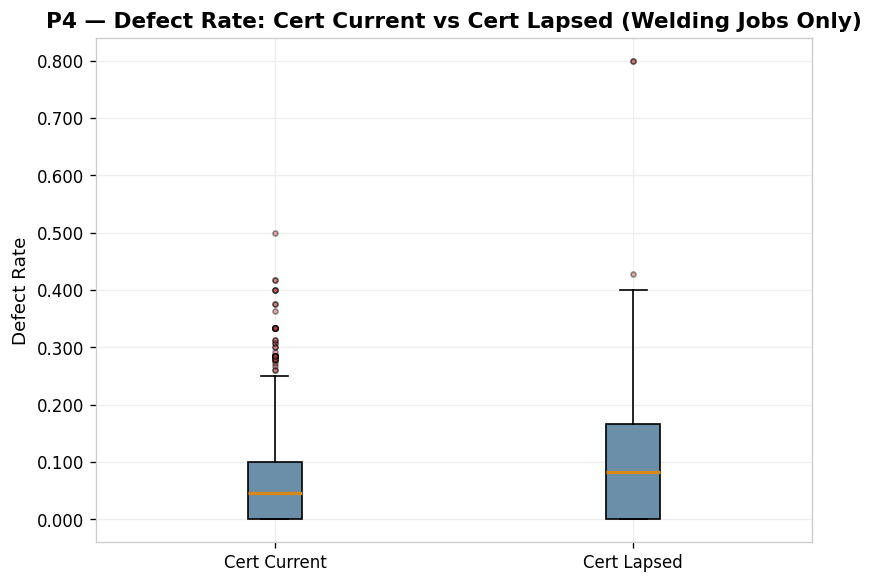

In [23]:
# Two-sample t-test: defect rate for welding jobs with lapsed cert vs current cert.
# Restricted to welding jobs only (requires_welding = True).
welding_jobs = df_dr[df_dr["requires_welding"] == True].copy()

lapsed  = welding_jobs[welding_jobs["welding_cert_mismatch"] == True]["defect_rate"]
current = welding_jobs[welding_jobs["welding_cert_mismatch"] == False]["defect_rate"]

t_stat, p_val = ttest_ind(lapsed, current, equal_var=False)

print("Welding jobs only — defect rate by certification status:")
print(f"  Cert lapsed  — n={len(lapsed):,}  mean={lapsed.mean():.4f}  std={lapsed.std():.4f}")
print(f"  Cert current — n={len(current):,}  mean={current.mean():.4f}  std={current.std():.4f}")
print(f"\nWelch t-test: t={t_stat:.3f}  p={p_val:.4f}")
print(f"Result: {'Statistically significant (p < 0.05)' if p_val < 0.05 else 'Not significant at p < 0.05'}")

# ── Box plot comparison ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(
    [current, lapsed],
    labels=["Cert Current", "Cert Lapsed"],
    patch_artist=True,
    boxprops=dict(facecolor=BRAND_ACCENT),
    medianprops=dict(color=WARN_AMBER, linewidth=2),
    flierprops=dict(marker="o", markersize=3, markerfacecolor=FAIL_RED, alpha=0.4)
)
ax.set_ylabel("Defect Rate")
ax.set_title("P4 — Defect Rate: Cert Current vs Cert Lapsed (Welding Jobs Only)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.3f}"))
plt.tight_layout()
plt.show()

### 6.3 OP007 Spotlight

In [24]:
# ── Config ────────────────────────────────────────────────────────────────
SPOTLIGHT_OPERATOR = "OP007"

op_df  = df_dr[df_dr["operator_id"] == SPOTLIGHT_OPERATOR]
all_df = df_dr[df_dr["operator_id"] != SPOTLIGHT_OPERATOR]

if op_df.empty:
    print(f"No records found for operator {SPOTLIGHT_OPERATOR}.")
else:
    print(f"Operator {SPOTLIGHT_OPERATOR} summary:")
    print(f"  Total work orders:   {len(op_df):,}")
    print(f"  Mean defect rate:    {op_df['defect_rate'].mean():.4f}")
    print(f"  All others mean:     {all_df['defect_rate'].mean():.4f}")
    print(f"  Multiplier:          {op_df['defect_rate'].mean() / all_df['defect_rate'].mean():.2f}x")
    print(f"  Welding cert status: {op_df['welding_cert_current'].iloc[0]}")
    print(f"  Cert level:          {op_df['cert_level'].iloc[0]}")
    print(f"  Specialization:      {op_df['specialization'].iloc[0]}")

    print(f"\n{SPOTLIGHT_OPERATOR} — defect rate by machine type:")
    display(
        op_df.groupby("machine_type")["defect_rate"]
        .agg(mean_defect_rate="mean", n_jobs="count")
        .sort_values("mean_defect_rate", ascending=False)
        .reset_index()
    )

Operator OP007 summary:
  Total work orders:   506
  Mean defect rate:    0.1040
  All others mean:     0.0600
  Multiplier:          1.73x
  Welding cert status: False
  Cert level:          Level 1
  Specialization:      Welding

OP007 — defect rate by machine type:


,machine_type,mean_defect_rate,n_jobs
0,Bending,0.1413,104
1,Welding,0.1206,257
2,Punching,0.0656,57
3,Laser Cutting,0.0364,88
